In [1]:
import os
import re
from tqdm import tqdm
from natsort import natsorted
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
dir_path = "./reports/"
dir_names = os.listdir(dir_path)
dir_names

['markitdown', 'ha_xiaomi_home', 'latexify_py']

In [3]:
temp = {
    "total_LOC": [],
    "issues_by_severity": defaultdict(list),
    "issues_by_confidence": defaultdict(list)
}

# Regex patterns to match relevant fields
patterns = {
    "total_LOC": r"Total lines of code:\s+(\d+)",
    "severity": r"\s*(Undefined|Low|Medium|High):\s+(\d+)",
    "confidence": r"\s*(Undefined|Low|Medium|High):\s+(\d+)"
}

# Function to extract data from a single report
def extract_report_data(report_text):
    # Extract total lines of code
    match = re.search(patterns["total_LOC"], report_text)
    if match:
        temp["total_LOC"].append(int(match.group(1)))

    # Extract issues by severity and confidence
    sections = report_text.split("Total issues (by severity):")
    if len(sections) > 1:
        severity_section = sections[1].split("Total issues (by confidence):")[0]
        confidence_section = sections[1].split("Total issues (by confidence):")[1]

        for line in severity_section.splitlines():
            match = re.match(patterns["severity"], line)
            if match:
                category, value = match.groups()
                temp["issues_by_severity"][category].append(int(value))

        for line in confidence_section.splitlines():
            match = re.match(patterns["confidence"], line)
            if match:
                category, value = match.groups()
                temp["issues_by_confidence"][category].append(int(value))

data = []
for dir_name in dir_names:
    data.append({f"{dir_name}": []})
    for file_name in tqdm(natsorted(os.listdir(dir_path + dir_name))):
        with open(dir_path + dir_name + "/" + file_name) as f:
            report_text = f.read()
            extract_report_data(report_text)
            data[-1][f"{dir_name}"].append(temp)
            temp = {
                "total_LOC": [],
                "issues_by_severity": defaultdict(list),
                "issues_by_confidence": defaultdict(list)
            }

100%|██████████| 100/100 [00:00<00:00, 1198.41it/s]


In [4]:
data

[{'markitdown': [{'total_LOC': [3531],
    'issues_by_severity': defaultdict(list,
                {'Undefined': [0], 'Low': [97], 'Medium': [2], 'High': [0]}),
    'issues_by_confidence': defaultdict(list,
                {'Undefined': [0], 'Low': [0], 'Medium': [0], 'High': [99]})},
   {'total_LOC': [3527],
    'issues_by_severity': defaultdict(list,
                {'Undefined': [0], 'Low': [97], 'Medium': [2], 'High': [0]}),
    'issues_by_confidence': defaultdict(list,
                {'Undefined': [0], 'Low': [0], 'Medium': [0], 'High': [99]})},
   {'total_LOC': [3527],
    'issues_by_severity': defaultdict(list,
                {'Undefined': [0], 'Low': [97], 'Medium': [2], 'High': [0]}),
    'issues_by_confidence': defaultdict(list,
                {'Undefined': [0], 'Low': [0], 'Medium': [0], 'High': [99]})},
   {'total_LOC': [3527],
    'issues_by_severity': defaultdict(list,
                {'Undefined': [0], 'Low': [97], 'Medium': [2], 'High': [0]}),
    'issues_by_confiden

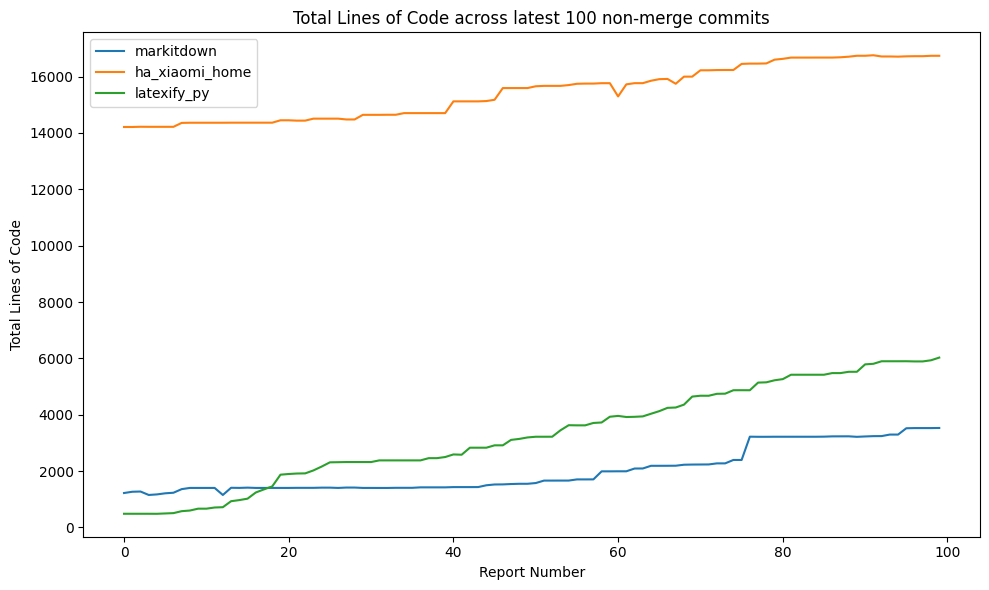

In [5]:
# Plotting
plt.figure(figsize=(10, 6))
for i, dir_name in enumerate(dir_names):
    x = range(len(data[i][dir_name]))
    y = [d["total_LOC"][0] for d in data[i][dir_name]][::-1]
    plt.plot(x, y, label=dir_name)
    plt.title("Total Lines of Code across latest 100 non-merge commits")
    plt.xlabel("Report Number")
    plt.ylabel("Total Lines of Code")
    plt.legend()
plt.tight_layout()
plt.show()

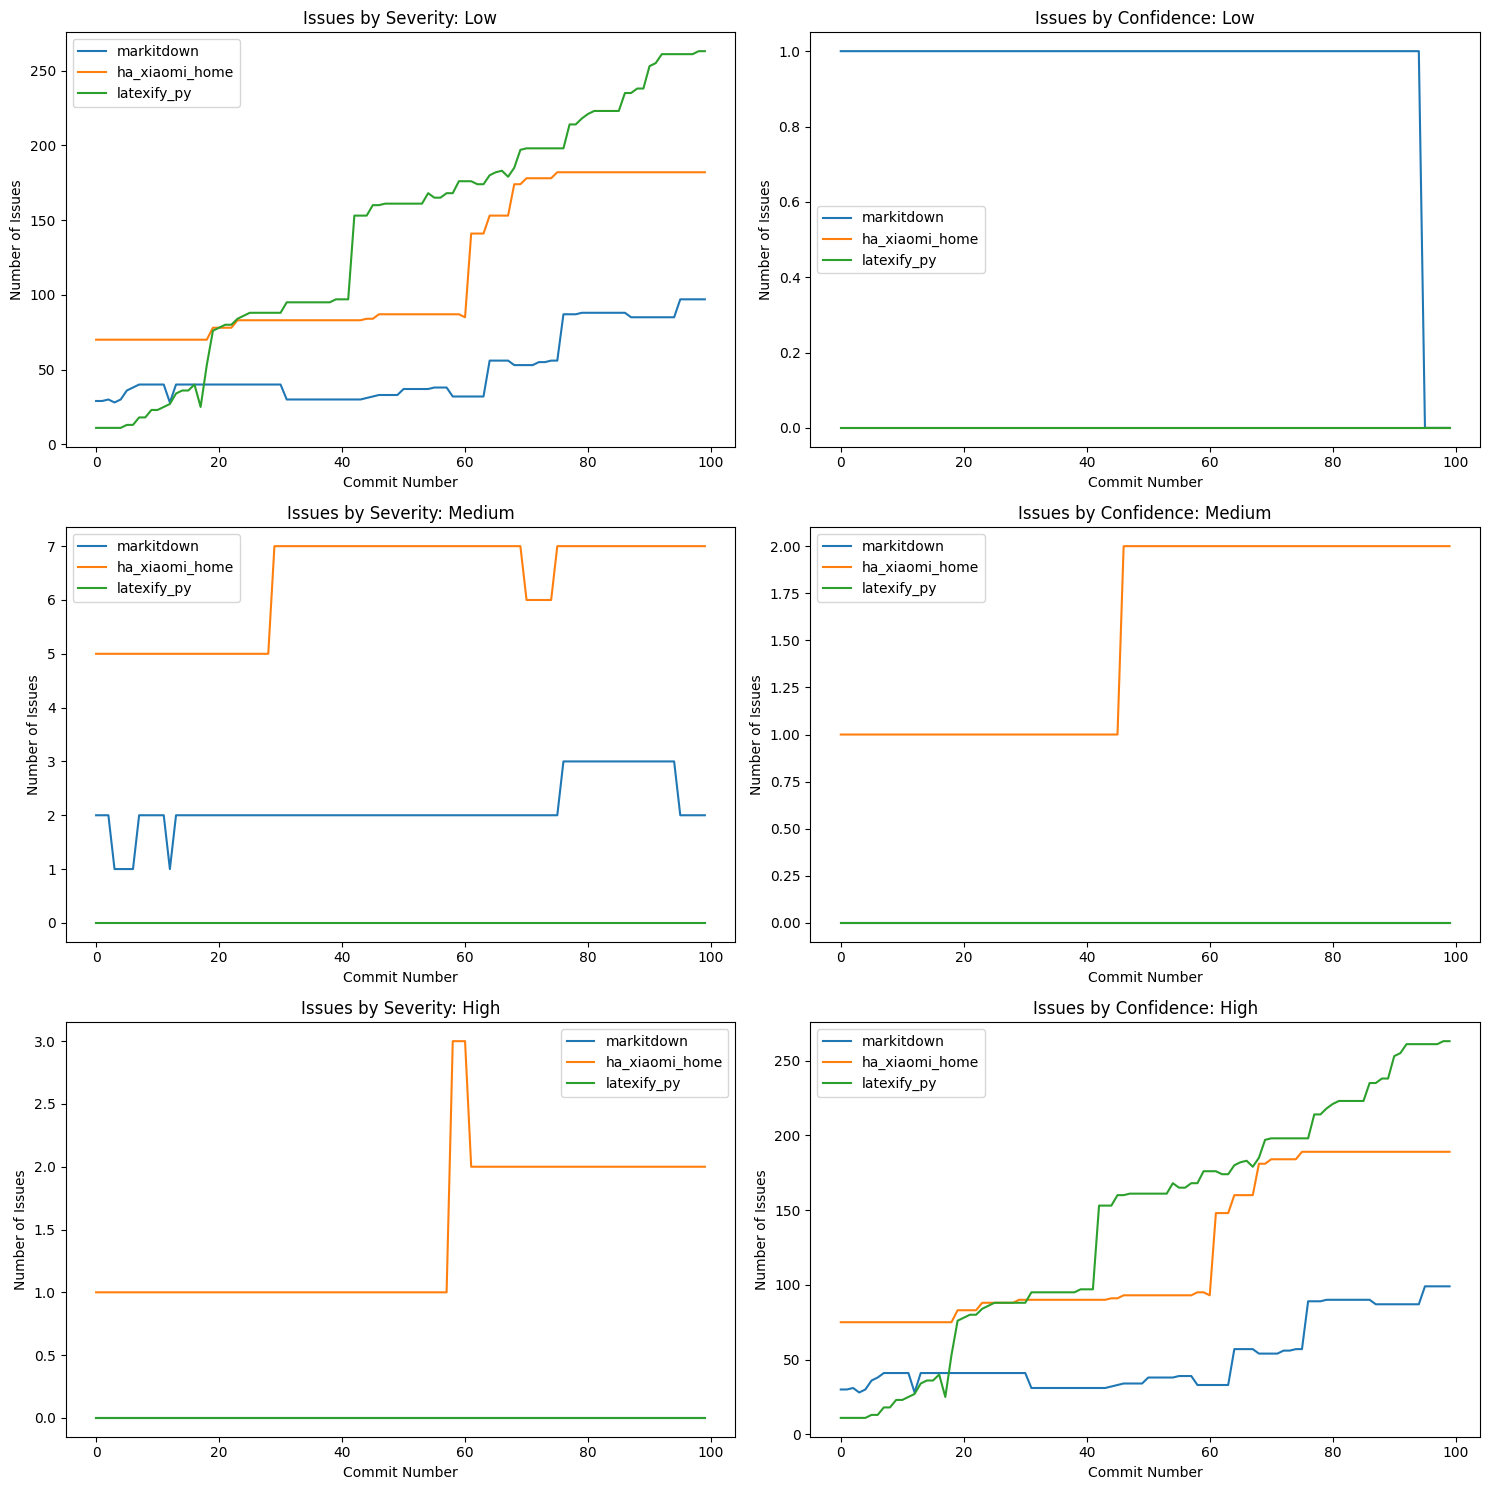

In [33]:
fig, axs = plt.subplots(3, 2, figsize=(15, 15))
for i, dir_name in enumerate(dir_names):
    x = range(len(data[i][dir_name]))
    for j, category in enumerate(["Low", "Medium", "High"]):
        y = [d["issues_by_severity"][category][0] for d in data[i][dir_name]][::-1]
        axs[j, 0].plot(x, y, label=dir_name)
        axs[j, 0].set_title(f"Issues by Severity: {category}")
        axs[j, 0].set_xlabel("Commit Number")
        axs[j, 0].set_ylabel("Number of Issues")
        axs[j, 0].legend()
    for j, category in enumerate(["Low", "Medium", "High"]):
        y = [d["issues_by_confidence"][category][0] for d in data[i][dir_name]][::-1]
        axs[j, 1].plot(x, y, label=dir_name)
        axs[j, 1].set_title(f"Issues by Confidence: {category}")
        axs[j, 1].set_xlabel("Commit Number")
        axs[j, 1].set_ylabel("Number of Issues")
        axs[j, 1].legend()
plt.tight_layout()
plt.show()

In [10]:
# Regex patterns to match CWE number and Issue description
patterns = {
    "issue": r">> Issue: \[(.*?)\] (.*?)\n",
    "cwe": r"CWE:\s+CWE-(\d+)"
}

def extract_issues(file_path):
    issues_list = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        report_text = file.read()
    
    # Find all issue matches
    issue_matches = list(re.finditer(patterns["issue"], report_text))
    
    for match in issue_matches:
        issue_code, issue_desc = match.groups()
        
        # Extract CWE number (look for it in text after the issue)
        cwe_match = re.search(patterns["cwe"], report_text[match.end():])
        
        if cwe_match:
            cwe_number = cwe_match.group(1)
            issues_list.append((cwe_number, f"[{issue_code}] {issue_desc}"))
    
    return issues_list

issues = []
for dir_name in dir_names:
    issues.append({f"{dir_name}": []})
    for file_name in tqdm(natsorted(os.listdir(dir_path + dir_name))):
        issue = extract_issues(dir_path + dir_name + "/" + file_name)
        issues[-1][f"{dir_name}"].append(issue)

100%|██████████| 100/100 [00:00<00:00, 413.32it/s]


In [19]:
issues

[{'markitdown': [[('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:assert_used] Use of assert detected. The enclosed code will be removed when compiling to optimised byte code.'),
    ('703',
     '[B101:ass

In [24]:
unique_issues_per_commit = []
for i, dir_name in enumerate(dir_names):
    unique_issues_per_commit.append({f"{dir_name}": []})
    for j, issue_list in enumerate(issues[i][dir_name]):
        unique_issues_per_commit[-1][f"{dir_name}"].append(list(set(issue_list)))

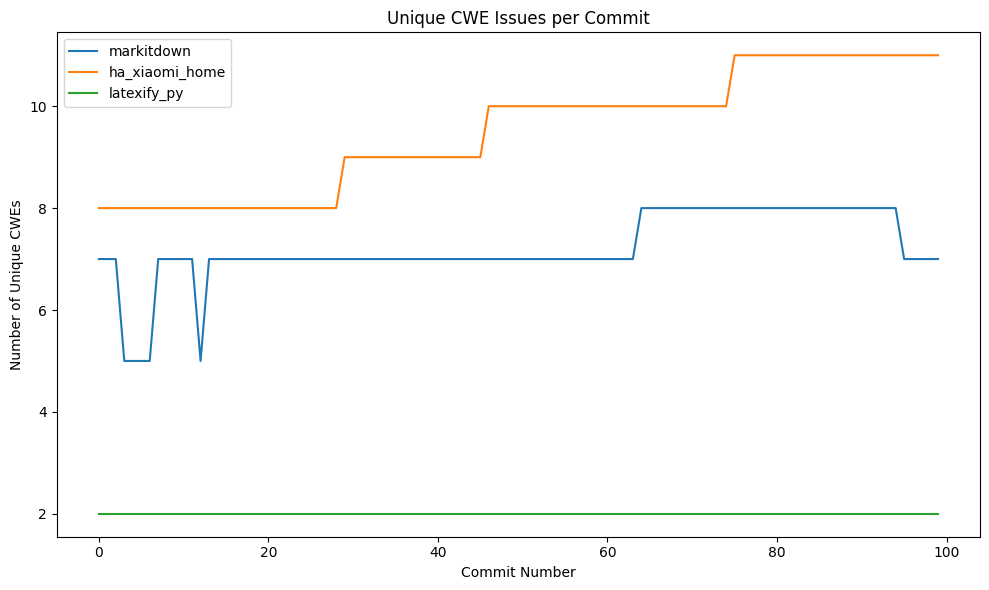

In [32]:
# plot number of unique issues per commit
plt.figure(figsize=(10, 6))
for i, dir_name in enumerate(dir_names):
    x = range(len(unique_issues_per_commit[i][dir_name]))
    y = [len(d) for d in unique_issues_per_commit[i][dir_name]][::-1]
    plt.plot(x, y, label=dir_name)
    plt.title("Unique CWE Issues per Commit")
    plt.xlabel("Commit Number")
    plt.ylabel("Number of Unique CWEs")
    plt.legend()
plt.tight_layout()
plt.show()